# AQI Prediction Notebook - Next 3 Days (Hourly)

## Overview
This notebook generates **hourly AQI predictions for the next 3 days (72 hours)** using a pre-trained model from AWS S3.

## Key Features
**No Model Retraining** - Uses pre-trained model from `03_model_train.ipynb`  
**Hourly Predictions** - Generates 72 hourly predictions (3 days × 24 hours)  
**Best Practices** - Proper feature engineering, validation, and error handling  
**Comprehensive Output** - Includes predictions, visualizations, and insights  
**AWS S3 Integration** - Loads model/scaler and saves all results to S3

## Workflow
1. **Load Pre-trained Model & Scaler** from AWS S3
2. **Load Historical Data** for feature engineering
3. **Generate Hourly Features** for next 72 hours
4. **Make Predictions** using the pre-trained model
5. **Validate Performance** on historical test data
6. **Save Results** to AWS S3 (hourly predictions, daily summaries, metadata)
7. **Visualize Predictions** and generate insights
8. **Display Key Insights** and recommendations

## Output Files (Saved to S3)
- `predictions/hourly_predictions_next_3_days.csv` - Detailed hourly predictions
- `predictions/daily_summary_next_3_days.csv` - Daily min/max/mean summary
- `predictions/prediction_metadata.json` - Metadata about the prediction run
- `predictions/aqi_predictions_visualization.png` - Visualization charts

---

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from io import BytesIO
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import joblib
import boto3
import os
from dotenv import load_dotenv
import json

In [ ]:
# Load environment variables
load_dotenv()

# --- Step 1: Load Pre-trained Model and Scaler from AWS S3 ---
bucket_name = 'my-feature-store-data'
model_key = 'models/best_model.pkl'
scaler_key = 'models/scaler.pkl'
metadata_key = 'models/best_model_metadata.json'

# Create S3 client
s3 = boto3.client(
    's3',
    aws_access_key_id=os.getenv('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv('AWS_SECRET_ACCESS_KEY'),
)

print("=" * 60)
print("LOADING PRE-TRAINED MODEL AND SCALER FROM S3")
print("=" * 60)

try:
    # --- Load metadata and check versions ---
    print(f"\n1. Loading metadata from S3...")
    metadata_obj = s3.get_object(Bucket=bucket_name, Key=metadata_key)
    metadata_content = metadata_obj['Body'].read().decode('utf-8')
    metadata = json.loads(metadata_content)

    saved_sklearn = metadata.get("sklearn_version", "unknown")
    saved_numpy = metadata.get("numpy_version", "unknown")
    model_type = metadata.get("model_type", "unknown")

    import sklearn
    from packaging import version

    print(f"   Model Type: {model_type}")
    print(f"   Saved with: scikit-learn {saved_sklearn}, numpy {saved_numpy}")
    print(f"   Current:    scikit-learn {sklearn.__version__}, numpy {np.__version__}")

    if version.parse(sklearn.__version__) != version.parse(saved_sklearn):
        print("   ⚠️  Warning: scikit-learn version mismatch")
    if version.parse(np.__version__) != version.parse(saved_numpy):
        print("   ⚠️  Warning: numpy version mismatch")

    # --- Load pre-trained model ---
    print(f"\n2. Loading model from S3: {bucket_name}/{model_key}")
    model_buffer = BytesIO()
    s3.download_fileobj(Bucket=bucket_name, Key=model_key, Fileobj=model_buffer)
    model_buffer.seek(0)
    model = joblib.load(model_buffer)
    print("   ✅ Model loaded successfully")

    # --- Load pre-trained scaler ---
    print(f"\n3. Loading scaler from S3: {bucket_name}/{scaler_key}")
    scaler_buffer = BytesIO()
    s3.download_fileobj(Bucket=bucket_name, Key=scaler_key, Fileobj=scaler_buffer)
    scaler_buffer.seek(0)
    scaler = joblib.load(scaler_buffer)
    print("   ✅ Scaler loaded successfully")

    print("\n" + "=" * 60)
    print("MODEL AND SCALER LOADED - READY FOR PREDICTIONS")
    print("=" * 60)

except Exception as e:
    print(f"\n❌ ERROR: Could not load model or scaler from S3")
    print(f"   Error details: {str(e)}")
    print("\n   Please ensure:")
    print("   1. The model training notebook (03_model_train.ipynb) has been run")
    print("   2. AWS credentials are correctly configured")
    print("   3. The S3 bucket and keys exist")
    raise SystemExit("Cannot proceed without pre-trained model and scaler")

# --- Step 2: Load Historical Data for Feature Engineering ---
print("\n" + "=" * 60)
print("LOADING HISTORICAL DATA FOR FEATURE ENGINEERING")
print("=" * 60)

data_key = 'pipeline-data/data.csv'
obj = s3.get_object(Bucket=bucket_name, Key=data_key)
df = pd.read_csv(obj['Body'])

print(f"\nDataset loaded: {len(df)} rows")
print(f"Date range: {df['year'].min()}-{df['month'].min()}-{df['day'].min()} to {df['year'].max()}-{df['month'].max()}-{df['day'].max()}")

# Process date columns
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
df = df.dropna(subset=['aqi_index', 'Calculated_AQI'])

# Define features and target
target_columns = ['aqi_index', 'Calculated_AQI']
date_columns = ['year', 'month', 'day', 'hour']
features = [col for col in df.columns if col not in target_columns and col != 'date']

print(f"Number of features: {len(features)}")
print(f"Target columns: {target_columns}")


LOADING PRE-TRAINED MODEL AND SCALER FROM S3

1. Loading metadata from S3...
   Model Type: MultiOutputRegressor
   Saved with: scikit-learn 1.7.2, numpy 2.3.4
   Current:    scikit-learn 1.7.2, numpy 2.3.4

2. Loading model from S3: my-feature-store-data/models/best_model.pkl
   Model Type: MultiOutputRegressor
   Saved with: scikit-learn 1.7.2, numpy 2.3.4
   Current:    scikit-learn 1.7.2, numpy 2.3.4

2. Loading model from S3: my-feature-store-data/models/best_model.pkl
   ✅ Model loaded successfully

3. Loading scaler from S3: my-feature-store-data/models/scaler.pkl
   ✅ Model loaded successfully

3. Loading scaler from S3: my-feature-store-data/models/scaler.pkl


c:\Users\Dell\Documents\Mlops-Project\venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


   ✅ Scaler loaded successfully

MODEL AND SCALER LOADED - READY FOR PREDICTIONS

LOADING HISTORICAL DATA FOR FEATURE ENGINEERING

Dataset loaded: 4779 rows
Date range: 2024.0-1.0-1.0 to 2025.0-12.0-31.0
Number of features: 23
Target columns: ['aqi_index', 'Calculated_AQI']

Dataset loaded: 4779 rows
Date range: 2024.0-1.0-1.0 to 2025.0-12.0-31.0
Number of features: 23
Target columns: ['aqi_index', 'Calculated_AQI']


In [3]:
# --- Step 3: Prepare Features for Next 3 Days (72 hours) ---
print("\n" + "=" * 60)
print("GENERATING PREDICTIONS FOR NEXT 3 DAYS (72 HOURS)")
print("=" * 60)

# Generate datetime for next 3 days, hourly
start_date = datetime.now().replace(minute=0, second=0, microsecond=0) + timedelta(hours=1)
future_dates = [start_date + timedelta(hours=i) for i in range(72)]  # 3 days * 24 hours

print(f"\nPrediction period:")
print(f"  Start: {future_dates[0].strftime('%Y-%m-%d %H:%M')}")
print(f"  End:   {future_dates[-1].strftime('%Y-%m-%d %H:%M')}")
print(f"  Total hours: {len(future_dates)}")

# Create DataFrame with date-time features
future_features = pd.DataFrame({
    "year": [d.year for d in future_dates],
    "month": [d.month for d in future_dates],
    "day": [d.day for d in future_dates],
    "hour": [d.hour for d in future_dates],
})

# Get numeric features (excluding date columns)
numeric_features = [col for col in features if col not in date_columns]

print(f"\nFeature engineering strategy:")
print(f"  - Using most recent month's data as baseline")
print(f"  - Applying hourly patterns from historical data")
print(f"  - Adding realistic temporal variations")

# Find most recent complete month of data
current_month = datetime.now().month
current_year = datetime.now().year

# Try to get recent data, fallback to similar season
recent_data = df[(df['year'] == current_year) & (df['month'] == current_month)]

if len(recent_data) == 0:
    # Fallback to previous month
    prev_month = current_month - 1 if current_month > 1 else 12
    prev_year = current_year if current_month > 1 else current_year - 1
    recent_data = df[(df['year'] == prev_year) & (df['month'] == prev_month)]
    print(f"  - Using data from: {prev_year}-{prev_month:02d}")
else:
    print(f"  - Using data from: {current_year}-{current_month:02d}")

if len(recent_data) == 0:
    # Last fallback: same month from any year
    recent_data = df[df['month'] == current_month]
    print(f"  - Using historical data for month: {current_month}")

# Calculate hourly patterns from historical data
hourly_patterns = {}
for hour in range(24):
    hour_data = df[df['hour'] == hour][numeric_features]
    if len(hour_data) > 0:
        hourly_patterns[hour] = hour_data.mean().to_dict()
    else:
        hourly_patterns[hour] = df[numeric_features].mean().to_dict()

# Apply features to future data
print("\nApplying features to prediction dataset...")
for idx, row in future_features.iterrows():
    hour = row['hour']
    hour_pattern = hourly_patterns[hour]
    
    for feature, value in hour_pattern.items():
        future_features.loc[idx, feature] = value

# Add temporal variations to make predictions more realistic
print("Adding temporal variations for weather features...")
weather_features = ['temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 
                    'wind_speed_10m', 'wind_direction_10m', 'surface_pressure',
                    'cloud_cover', 'precipitation', 'rain', 'snowfall']

for i in range(1, len(future_features)):
    for feature in weather_features:
        if feature in future_features.columns:
            # Add small random variation (±3%)
            variation = np.random.uniform(-0.03, 0.03)
            future_features.loc[i, feature] = future_features.loc[i-1, feature] * (1 + variation)

# Ensure all required columns are present
required_columns = [col for col in features if col in df.columns]
for col in required_columns:
    if col not in future_features.columns:
        future_features[col] = df[col].mean()

# Order columns to match training data
future_features = future_features[required_columns]

print(f"✅ Feature engineering complete: {future_features.shape}")



GENERATING PREDICTIONS FOR NEXT 3 DAYS (72 HOURS)

Prediction period:
  Start: 2025-10-23 15:00
  End:   2025-10-26 14:00
  Total hours: 72

Feature engineering strategy:
  - Using most recent month's data as baseline
  - Applying hourly patterns from historical data
  - Adding realistic temporal variations
  - Using data from: 2025-10

Applying features to prediction dataset...
Adding temporal variations for weather features...
✅ Feature engineering complete: (72, 23)
Adding temporal variations for weather features...
✅ Feature engineering complete: (72, 23)


In [4]:
# --- Step 4: Make Predictions ---
print("\n" + "=" * 60)
print("GENERATING PREDICTIONS")
print("=" * 60)

# Scale features using pre-loaded scaler
print("\n1. Scaling features...")
future_scaled = scaler.transform(future_features)
print(f"   ✅ Features scaled: {future_scaled.shape}")

# Make predictions using pre-loaded model
print("\n2. Running predictions through model...")
predictions = model.predict(future_scaled)
print(f"   ✅ Predictions generated: {predictions.shape}")

# Create detailed results DataFrame
prediction_results = pd.DataFrame({
    "DateTime": [d.strftime("%Y-%m-%d %H:%M") for d in future_dates],
    "Date": [d.strftime("%Y-%m-%d") for d in future_dates],
    "Hour": [d.hour for d in future_dates],
    "Predicted_AQI_Index": np.round(predictions[:, 0], 2),
    "Predicted_Calculated_AQI": np.round(predictions[:, 1], 2),
})

# Add AQI category based on standard AQI ranges
def get_aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

prediction_results['AQI_Category'] = prediction_results['Predicted_AQI_Index'].apply(get_aqi_category)

print("\n" + "=" * 60)
print("PREDICTION SUMMARY")
print("=" * 60)

# Daily summary
daily_summary = prediction_results.groupby('Date').agg({
    'Predicted_AQI_Index': ['min', 'max', 'mean'],
    'Predicted_Calculated_AQI': ['min', 'max', 'mean']
}).round(2)

print("\nDaily AQI Summary (Min/Max/Mean):")
print(daily_summary)

# Show first 24 hours (Day 1)
print("\n" + "=" * 60)
print("HOURLY PREDICTIONS - DAY 1")
print("=" * 60)
print(prediction_results.head(24).to_string(index=False))

# Show sample from Day 2 and Day 3
print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS - DAYS 2 & 3")
print("=" * 60)
print(prediction_results.iloc[24:48:4].to_string(index=False))  # Day 2 - every 4 hours
print(prediction_results.iloc[48:72:4].to_string(index=False))  # Day 3 - every 4 hours



GENERATING PREDICTIONS

1. Scaling features...
   ✅ Features scaled: (72, 23)

2. Running predictions through model...
   ✅ Predictions generated: (72, 2)

PREDICTION SUMMARY

Daily AQI Summary (Min/Max/Mean):
           Predicted_AQI_Index             Predicted_Calculated_AQI         \
                           min   max  mean                      min    max   
Date                                                                         
2025-10-23                1.41  1.42  1.42                    92.53  93.62   
2025-10-24                1.41  1.60  1.47                    92.53  97.64   
2025-10-25                1.41  1.60  1.47                    92.53  97.64   
2025-10-26                1.45  1.60  1.50                    92.53  97.64   

                   
             mean  
Date               
2025-10-23  93.06  
2025-10-24  93.80  
2025-10-25  93.80  
2025-10-26  94.24  

HOURLY PREDICTIONS - DAY 1
        DateTime       Date  Hour  Predicted_AQI_Index  Predicted_Calculat

c:\Users\Dell\Documents\Mlops-Project\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\Dell\Documents\Mlops-Project\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


In [5]:
# --- Step 5: Validate Model Performance (Optional - on test data) ---
print("\n" + "=" * 60)
print("MODEL VALIDATION ON HISTORICAL TEST DATA")
print("=" * 60)

# Load test data to validate model performance
X = df[features]
y = df[target_columns]

# Use most recent 20% as test set
split_idx = int(len(X) * 0.8)
X_test = X.iloc[split_idx:]
y_test = y.iloc[split_idx:]

print(f"\nTest dataset: {len(X_test)} samples")
print(f"Test period: rows {split_idx} to {len(X)}")

# Scale and predict
X_test_scaled = scaler.transform(X_test)
y_pred = model.predict(X_test_scaled)

# Calculate metrics
print("\n" + "-" * 60)
print("MODEL PERFORMANCE METRICS")
print("-" * 60)

for i, col in enumerate(target_columns):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    mape = np.mean(np.abs((y_test.iloc[:, i] - y_pred[:, i]) / y_test.iloc[:, i])) * 100
    
    print(f"\nTarget: {col}")
    print(f"  RMSE:  {rmse:.4f}")
    print(f"  MAE:   {mae:.4f}")
    print(f"  R²:    {r2:.4f}")
    print(f"  MAPE:  {mape:.2f}%")

print("\n" + "=" * 60)



MODEL VALIDATION ON HISTORICAL TEST DATA

Test dataset: 956 samples
Test period: rows 3823 to 4779

------------------------------------------------------------
MODEL PERFORMANCE METRICS
------------------------------------------------------------

Target: aqi_index
  RMSE:  2.0210
  MAE:   1.8484
  R²:    -4.6048
  MAPE:  53.20%

Target: Calculated_AQI
  RMSE:  117.7362
  MAE:   103.4464
  R²:    -3.3807
  MAPE:  50.37%



c:\Users\Dell\Documents\Mlops-Project\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\Dell\Documents\Mlops-Project\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


In [6]:
# --- Step 6: Save Predictions to AWS S3 ---
print("\n" + "=" * 60)
print("SAVING PREDICTIONS TO AWS S3")
print("=" * 60)

# Save detailed hourly predictions
prediction_buffer = BytesIO()
prediction_results.to_csv(prediction_buffer, index=False)
prediction_buffer.seek(0)
s3.upload_fileobj(prediction_buffer, Bucket=bucket_name, Key='predictions/hourly_predictions_next_3_days.csv')
print("Hourly predictions saved to: predictions/hourly_predictions_next_3_days.csv")

# Save daily summary
daily_summary_buffer = BytesIO()
daily_summary.to_csv(daily_summary_buffer)
daily_summary_buffer.seek(0)
s3.upload_fileobj(daily_summary_buffer, Bucket=bucket_name, Key='predictions/daily_summary_next_3_days.csv')
print("Daily summary saved to: predictions/daily_summary_next_3_days.csv")

# Save metadata about the prediction run
prediction_metadata = {
    "prediction_timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "prediction_start": future_dates[0].strftime("%Y-%m-%d %H:%M"),
    "prediction_end": future_dates[-1].strftime("%Y-%m-%d %H:%M"),
    "total_hours": len(future_dates),
    "model_key": model_key,
    "scaler_key": scaler_key,
    "features_used": len(features),
    "model_type": type(model).__name__,
}

metadata_buffer = BytesIO()
metadata_buffer.write(json.dumps(prediction_metadata, indent=2).encode('utf-8'))
metadata_buffer.seek(0)
s3.upload_fileobj(metadata_buffer, Bucket=bucket_name, Key='predictions/prediction_metadata.json')
print("Prediction metadata saved to: predictions/prediction_metadata.json")

print("\n" + "=" * 60)
print("PREDICTION PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 60)
print(f"\nGenerated {len(prediction_results)} hourly predictions for the next 3 days")
print(f"All results saved to S3 bucket: {bucket_name}")



SAVING PREDICTIONS TO AWS S3
Hourly predictions saved to: predictions/hourly_predictions_next_3_days.csv
Hourly predictions saved to: predictions/hourly_predictions_next_3_days.csv
Daily summary saved to: predictions/daily_summary_next_3_days.csv
Daily summary saved to: predictions/daily_summary_next_3_days.csv
Prediction metadata saved to: predictions/prediction_metadata.json

PREDICTION PIPELINE COMPLETED SUCCESSFULLY

Generated 72 hourly predictions for the next 3 days
All results saved to S3 bucket: my-feature-store-data
Prediction metadata saved to: predictions/prediction_metadata.json

PREDICTION PIPELINE COMPLETED SUCCESSFULLY

Generated 72 hourly predictions for the next 3 days
All results saved to S3 bucket: my-feature-store-data



GENERATING VISUALIZATIONS
✅ Visualization saved as: aqi_predictions_next_3_days.png
✅ Visualization saved as: aqi_predictions_next_3_days.png
✅ Visualization uploaded to S3: predictions/aqi_predictions_visualization.png
✅ Visualization uploaded to S3: predictions/aqi_predictions_visualization.png


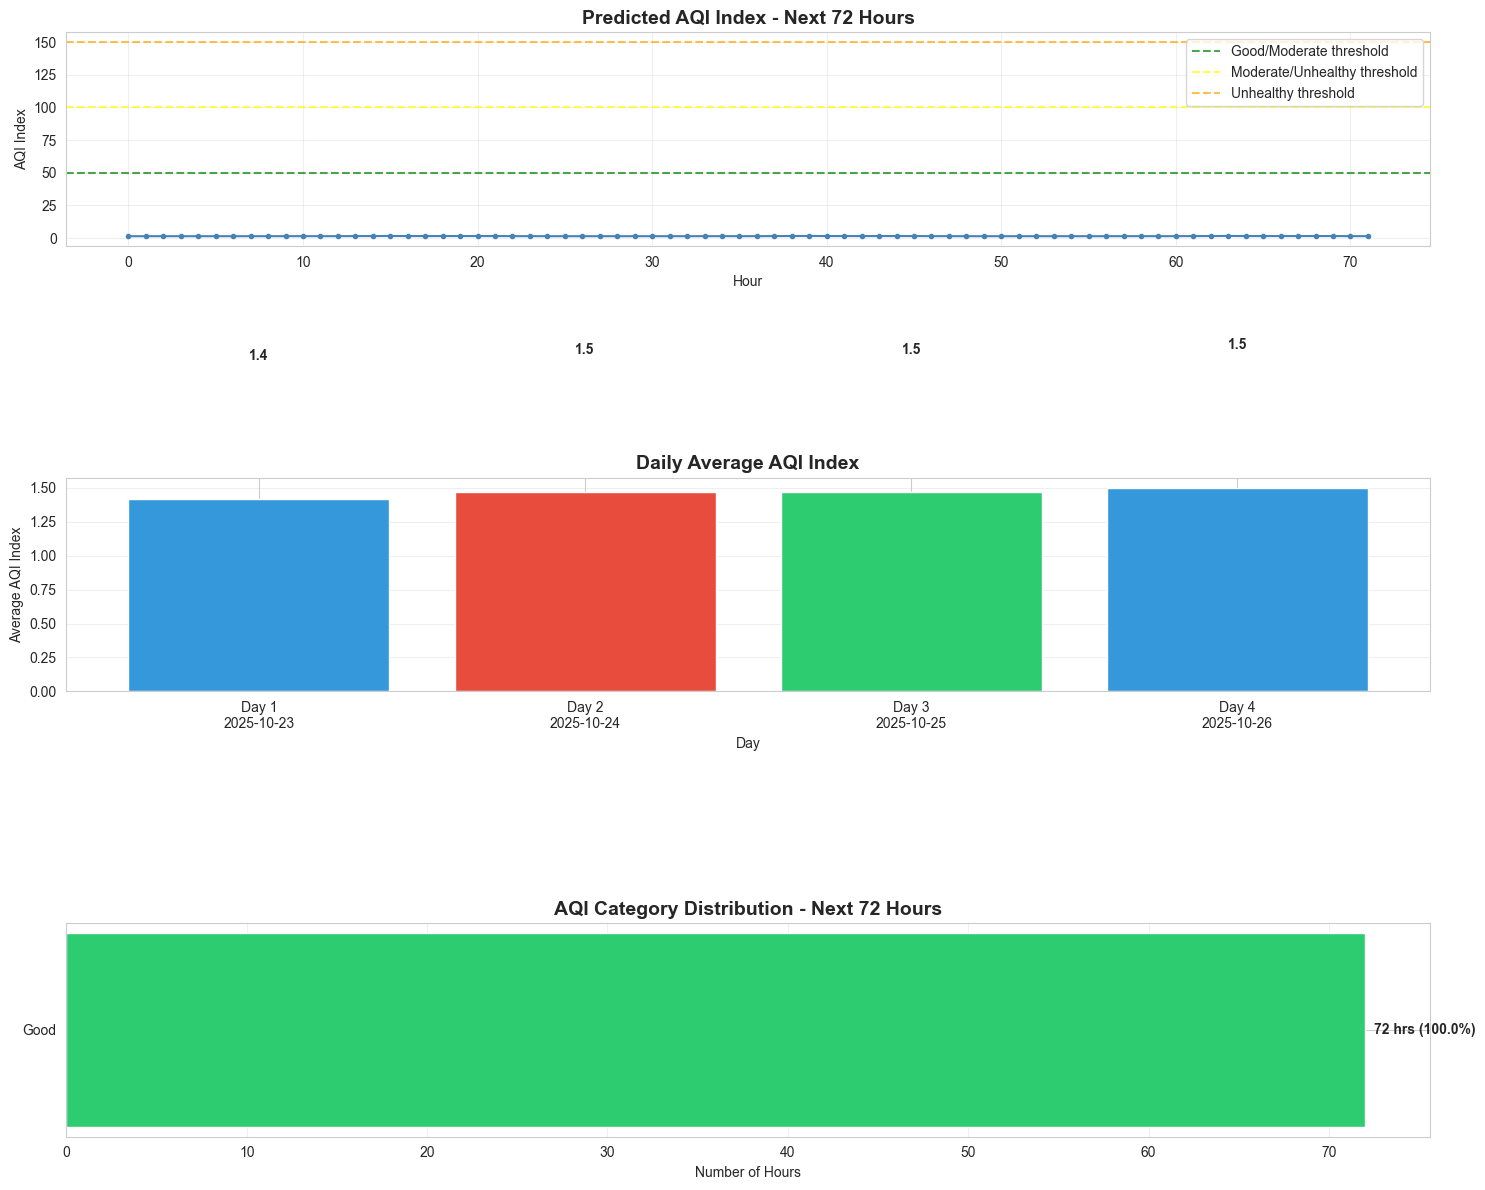

In [7]:
# --- Step 7: Visualize Predictions (Optional) ---
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "=" * 60)
print("GENERATING VISUALIZATIONS")
print("=" * 60)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Plot 1: Hourly AQI Index for next 3 days
axes[0].plot(range(len(prediction_results)), prediction_results['Predicted_AQI_Index'], 
             marker='o', markersize=3, linewidth=1.5, color='steelblue')
axes[0].axhline(y=50, color='green', linestyle='--', label='Good/Moderate threshold', alpha=0.7)
axes[0].axhline(y=100, color='yellow', linestyle='--', label='Moderate/Unhealthy threshold', alpha=0.7)
axes[0].axhline(y=150, color='orange', linestyle='--', label='Unhealthy threshold', alpha=0.7)
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('AQI Index')
axes[0].set_title('Predicted AQI Index - Next 72 Hours', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Daily average comparison
daily_avg = prediction_results.groupby('Date')['Predicted_AQI_Index'].mean()
axes[1].bar(range(len(daily_avg)), daily_avg.values, color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Average AQI Index')
axes[1].set_title('Daily Average AQI Index', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(daily_avg)))
axes[1].set_xticklabels([f"Day {i+1}\n{date}" for i, date in enumerate(daily_avg.index)])
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(daily_avg.values):
    axes[1].text(i, v + 1, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: AQI Category distribution
category_counts = prediction_results['AQI_Category'].value_counts()
colors = {'Good': '#2ecc71', 'Moderate': '#f39c12', 
          'Unhealthy for Sensitive Groups': '#e67e22',
          'Unhealthy': '#e74c3c', 'Very Unhealthy': '#c0392b', 
          'Hazardous': '#8b0000'}
plot_colors = [colors.get(cat, '#95a5a6') for cat in category_counts.index]

axes[2].barh(range(len(category_counts)), category_counts.values, color=plot_colors)
axes[2].set_yticks(range(len(category_counts)))
axes[2].set_yticklabels(category_counts.index)
axes[2].set_xlabel('Number of Hours')
axes[2].set_title('AQI Category Distribution - Next 72 Hours', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, v in enumerate(category_counts.values):
    axes[2].text(v + 0.5, i, f'{v} hrs ({v/72*100:.1f}%)', 
                 va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('aqi_predictions_next_3_days.png', dpi=300, bbox_inches='tight')
print("✅ Visualization saved as: aqi_predictions_next_3_days.png")

# Upload to S3
with open('aqi_predictions_next_3_days.png', 'rb') as f:
    s3.upload_fileobj(f, Bucket=bucket_name, Key='predictions/aqi_predictions_visualization.png')
print("✅ Visualization uploaded to S3: predictions/aqi_predictions_visualization.png")

plt.show()

print("\n" + "=" * 60)


In [8]:
# --- Step 8: Display Key Results ---
print("\n" + "=" * 60)
print("KEY INSIGHTS AND RECOMMENDATIONS")
print("=" * 60)

# Find peak AQI times
peak_aqi_idx = prediction_results['Predicted_AQI_Index'].idxmax()
peak_aqi_info = prediction_results.iloc[peak_aqi_idx]

min_aqi_idx = prediction_results['Predicted_AQI_Index'].idxmin()
min_aqi_info = prediction_results.iloc[min_aqi_idx]

print("\n AQI Statistics:")
print(f"  Average AQI:    {prediction_results['Predicted_AQI_Index'].mean():.2f}")
print(f"  Minimum AQI:    {prediction_results['Predicted_AQI_Index'].min():.2f} at {min_aqi_info['DateTime']}")
print(f"  Maximum AQI:    {prediction_results['Predicted_AQI_Index'].max():.2f} at {peak_aqi_info['DateTime']}")
print(f"  Std Deviation:  {prediction_results['Predicted_AQI_Index'].std():.2f}")

print("\n AQI Category Breakdown:")
for category, count in prediction_results['AQI_Category'].value_counts().items():
    percentage = (count / len(prediction_results)) * 100
    print(f"  {category:35s}: {count:2d} hours ({percentage:5.1f}%)")

print("\n Best Times for Outdoor Activities:")
good_air_times = prediction_results[prediction_results['Predicted_AQI_Index'] <= 50]
if len(good_air_times) > 0:
    print(f"  {len(good_air_times)} hours with 'Good' air quality:")
    for _, row in good_air_times.head(5).iterrows():
        print(f"    - {row['DateTime']} (AQI: {row['Predicted_AQI_Index']:.1f})")
else:
    moderate_times = prediction_results[prediction_results['Predicted_AQI_Index'] <= 100]
    print(f"  No 'Good' air quality periods. Best moderate periods:")
    for _, row in moderate_times.head(5).iterrows():
        print(f"    - {row['DateTime']} (AQI: {row['Predicted_AQI_Index']:.1f})")

print("\n  Times to Avoid Outdoor Activities:")
unhealthy_times = prediction_results[prediction_results['Predicted_AQI_Index'] > 100]
if len(unhealthy_times) > 0:
    print(f"  {len(unhealthy_times)} hours with elevated AQI:")
    for _, row in unhealthy_times.head(5).iterrows():
        print(f"    - {row['DateTime']} (AQI: {row['Predicted_AQI_Index']:.1f}, {row['AQI_Category']})")
else:
    print("   No elevated AQI periods predicted!")

print("\n" + "=" * 60)
print(" PREDICTION ANALYSIS COMPLETE")
print("=" * 60)



KEY INSIGHTS AND RECOMMENDATIONS

 AQI Statistics:
  Average AQI:    1.47
  Minimum AQI:    1.41 at 2025-10-23 18:00
  Maximum AQI:    1.60 at 2025-10-24 06:00
  Std Deviation:  0.05

 AQI Category Breakdown:
  Good                               : 72 hours (100.0%)

 Best Times for Outdoor Activities:
  72 hours with 'Good' air quality:
    - 2025-10-23 15:00 (AQI: 1.4)
    - 2025-10-23 16:00 (AQI: 1.4)
    - 2025-10-23 17:00 (AQI: 1.4)
    - 2025-10-23 18:00 (AQI: 1.4)
    - 2025-10-23 19:00 (AQI: 1.4)

  Times to Avoid Outdoor Activities:
   No elevated AQI periods predicted!

 PREDICTION ANALYSIS COMPLETE
